<a href="https://colab.research.google.com/github/TanyaGupta37/ML-Lab/blob/main/Test_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


try:
    df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i (1).csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Dataset not found. Please ensure 'train_u6lujuX_CVtuZ9i (1).csv' is in '/content/'.")
    df = pd.DataFrame()

display(df.head())

Dataset loaded successfully.


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Data Preprocessing



In [ ]:
if not df.empty:
    print("\nDataset Info:")
    df.info()

    print("\nMissing values per column:")
    display(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

Missing values per column:


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
if not df.empty:

    df = df.drop('Loan_ID', axis=1)
    X = df.drop('Loan_Status', axis=1)
    y = df['Loan_Status']


    le = LabelEncoder()
    y = le.fit_transform(y)

    categorical_cols = X.select_dtypes(include='object').columns
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])


    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_cols),
            ('cat', categorical_transformer, categorical_cols)
        ])


    X_processed = preprocessor.fit_transform(X)

    onehot_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)
    all_feature_names = list(numerical_cols) + list(onehot_feature_names)

    X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

    print("\nShape of X after preprocessing:", X_processed_df.shape)
    print("\nFirst 5 rows of preprocessed X:")
    display(X_processed_df.head())


    X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, test_size=0.2, random_state=42, stratify=y)

    print("\nTraining and testing sets created successfully.")
    print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
else:
    print("DataFrame is empty, skipping preprocessing.")


Shape of X after preprocessing: (614, 20)

First 5 rows of preprocessed X:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,0.072991,-0.554487,0.000000,0.279851,0.45164,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.134412,-0.038732,-0.219273,0.279851,0.45164,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2,-0.393747,-0.554487,-0.957641,0.279851,0.45164,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-0.462062,0.251980,-0.314547,0.279851,0.45164,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,0.097728,-0.554487,-0.064454,0.279851,0.45164,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0



Training and testing sets created successfully.
X_train shape: (491, 20), y_train shape: (491,)
X_test shape: (123, 20), y_test shape: (123,)


### Data Visualization



/tmp/ipykernel_1715/3793190304.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


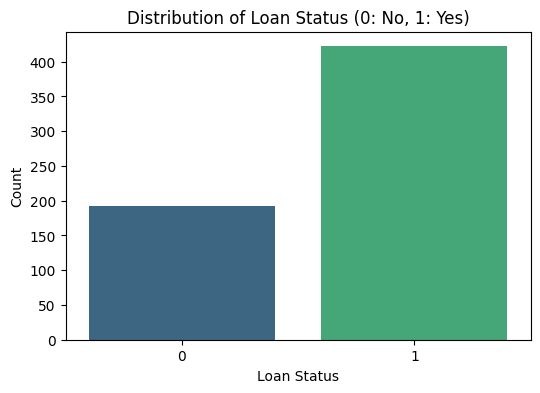

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'X_processed_df' in locals() and not X_processed_df.empty:

    plt.figure(figsize=(6, 4))
    sns.countplot(x=y, palette='viridis')
    plt.title('Distribution of Loan Status (0: No, 1: Yes)')
    plt.xlabel('Loan Status')
    plt.ylabel('Count')
    plt.show()



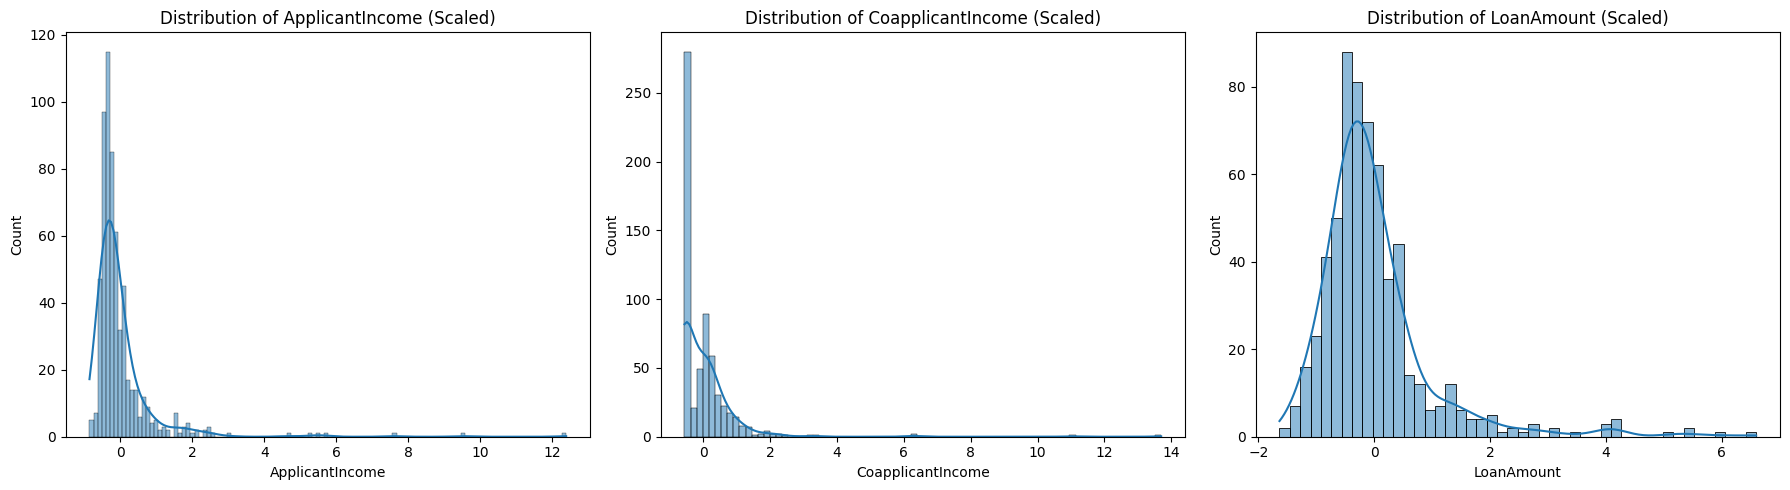

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(X_processed_df['ApplicantIncome'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of ApplicantIncome (Scaled)')

sns.histplot(X_processed_df['CoapplicantIncome'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of CoapplicantIncome (Scaled)')

sns.histplot(X_processed_df['LoanAmount'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of LoanAmount (Scaled)')
plt.tight_layout()
plt.show()

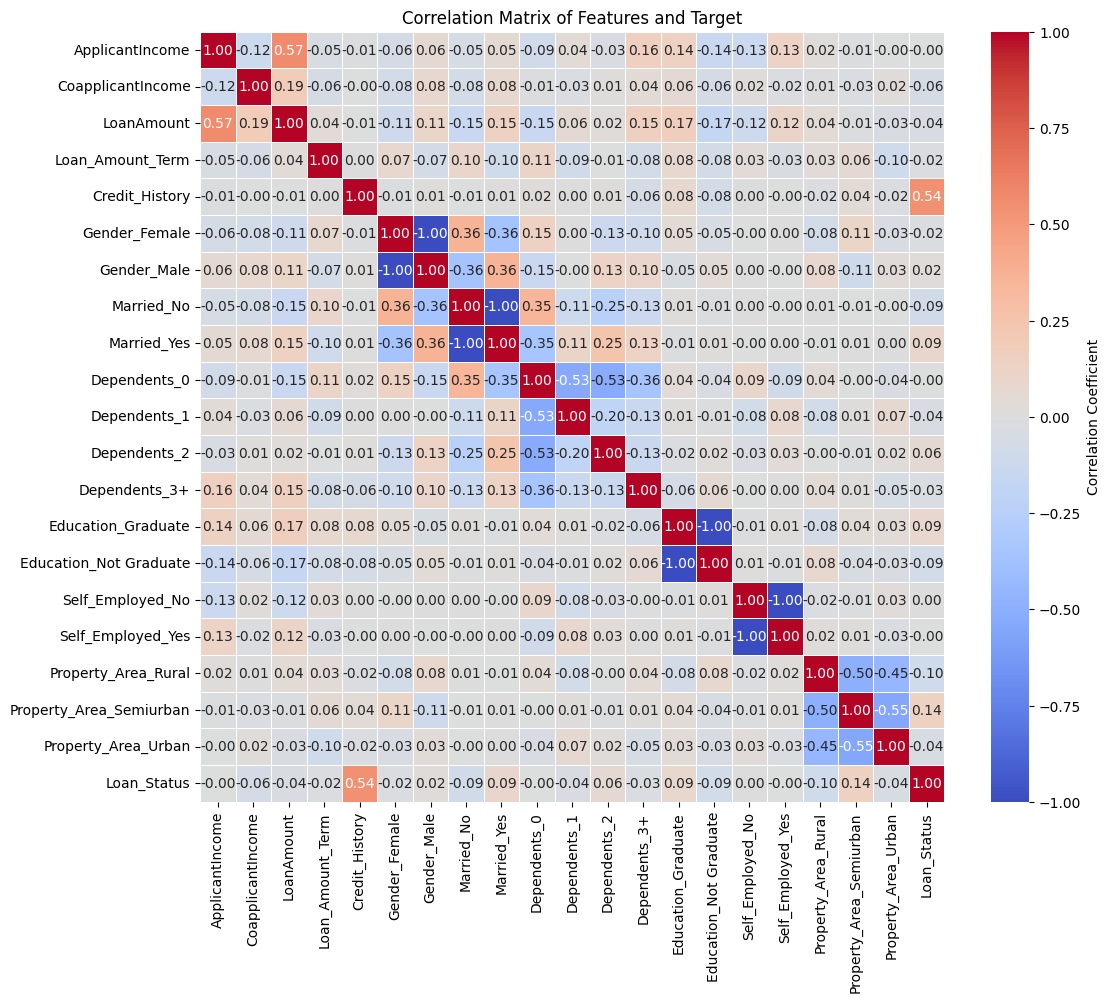

In [ ]:
if 'X_processed_df' in locals() and not X_processed_df.empty and 'y' in locals():
    # Combine X_processed_df and y for correlation
    df_corr = X_processed_df.copy()
    df_corr['Loan_Status'] = y

    plt.figure(figsize=(12, 10))
    sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation Coefficient'})
    plt.title('Correlation Matrix of Features and Target')
    plt.show()
else:
    print("No preprocessed data or target variable available for correlation heatmap.")

### Model Training and Evaluation



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n--- Training Gradient Boosting Classifier ---")

gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc.fit(X_train, y_train)

print("Model training complete.")


y_pred = gbc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Training Gradient Boosting Classifier ---
Model training complete.

Accuracy: 0.8211

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.55      0.66        38
           1       0.82      0.94      0.88        85

    accuracy                           0.82       123
   macro avg       0.82      0.75      0.77       123
weighted avg       0.82      0.82      0.81       123



### Model Evaluation Visualization


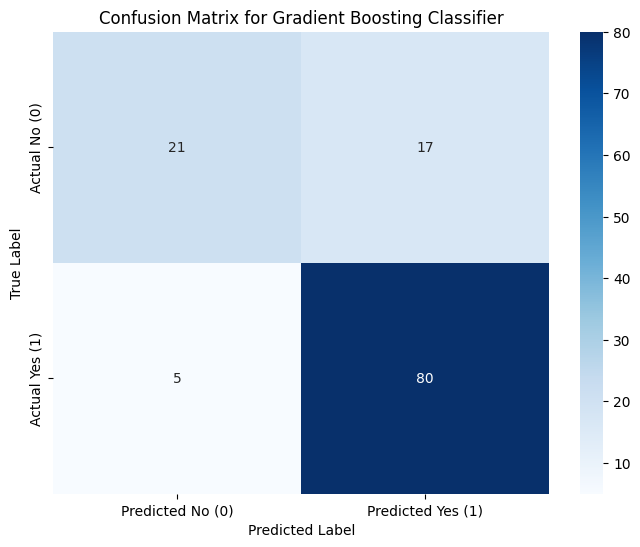

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No (0)', 'Predicted Yes (1)'],
            yticklabels=['Actual No (0)', 'Actual Yes (1)'])
plt.title('Confusion Matrix for Gradient Boosting Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

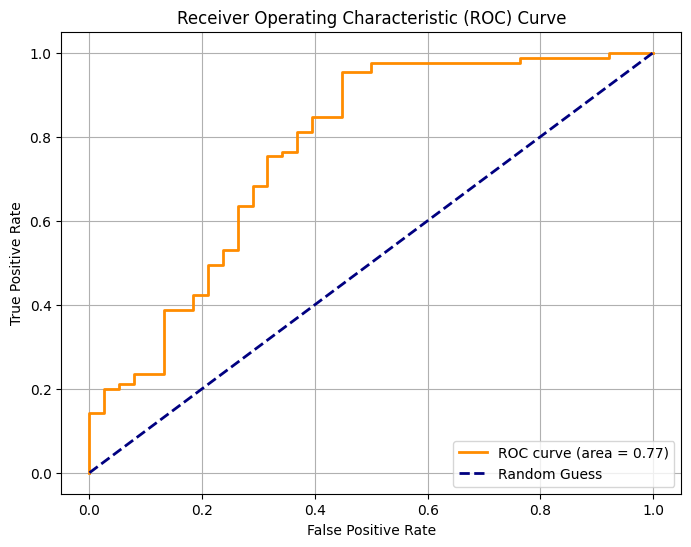

In [ ]:
from sklearn.metrics import roc_curve, auc

y_proba = gbc.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()